<a href="https://colab.research.google.com/github/SofianeBelkattal/Stock_Clustering_with_K-Means/blob/main/diversification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

image.png

**Part1: Daily Analysis (Using Intraday Realized Measures)**



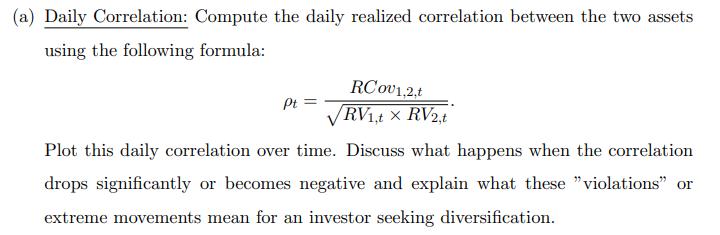

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


In [2]:
os.getcwd()

'/content'

In [12]:
data=pd.read_excel("data.xlsx")
data.head()

,date,RV_JNJ,RV_JPM,rcov
0,2015-01-02,0.000092,0.000146,0.000048
1,2015-01-05,0.000077,0.000185,0.000044
2,2015-01-06,0.000147,0.000297,0.000092
3,2015-01-07,0.000107,0.000243,0.000072
4,2015-01-08,0.000049,0.000124,0.000022


In [13]:
data['daily_corr'] = data['rcov'] / (np.sqrt(data['RV_JNJ']) * np.sqrt(data['RV_JPM']))
data.head()

,date,RV_JNJ,RV_JPM,rcov,daily_corr
0,2015-01-02,0.000092,0.000146,0.000048,0.414501
1,2015-01-05,0.000077,0.000185,0.000044,0.369340
2,2015-01-06,0.000147,0.000297,0.000092,0.438037
3,2015-01-07,0.000107,0.000243,0.000072,0.447211
4,2015-01-08,0.000049,0.000124,0.000022,0.285529


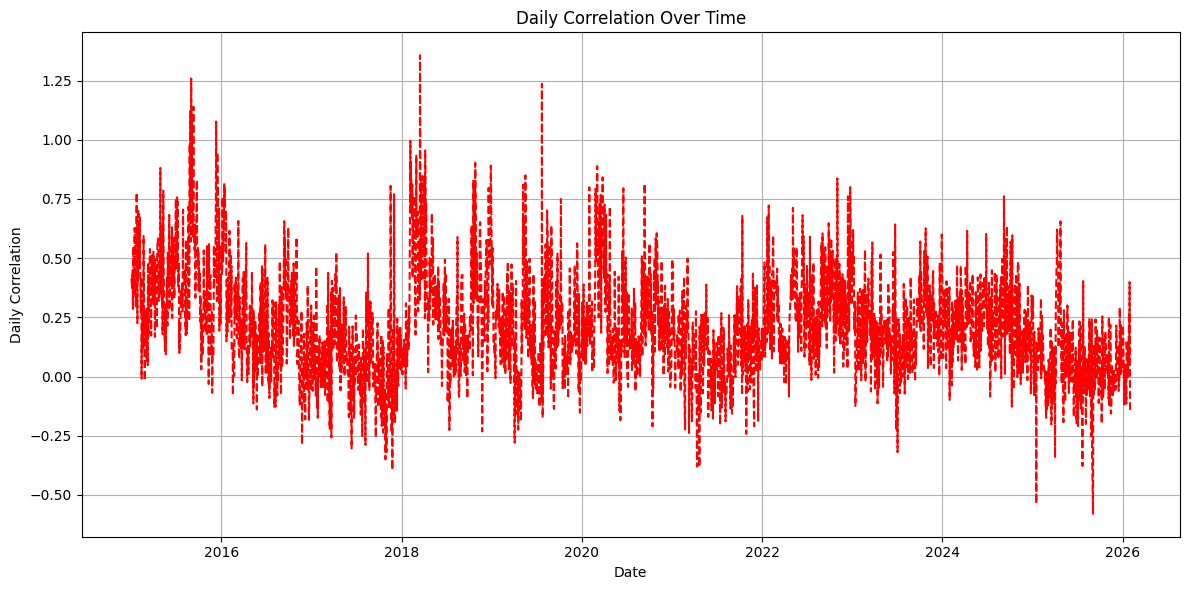

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(data['date'], data['daily_corr'], 'r--')
plt.title('Daily Correlation Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Correlation')
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:** The daily correlation between JNJ and JPM fluctuates between roughly -0.5 and 0.5 over the 2014–2026 period with no stable long-run level, and the occasional spikes above 1.0 are not economically meaningful but rather measurement artifacts arising from microstructure noise and asynchronous sampling in the computation of realized variances and covariances from high-frequency data. Several episodes of sharp drops or negative correlation stand out (most notably during COVID-19 in 2020, where JPM sold off heavily on rate cuts and credit stress while JNJ benefited from its pharmaceutical exposure, causing the two assets to move in opposite directions) alongside similar divergences in 2018 during the Fed tightening cycle and in 2025–2026 where a fresh negative spike is visible. For a diversification-seeking investor, these episodes are the most valuable moments in the sample, as a negative or near-zero correlation genuinely reduces portfolio variance beyond what either asset offers alone; however, they are unpredictable and fragile, since during broad market stress equity correlations tend to converge toward 1 as investors liquidate indiscriminately, meaning the sector distance between JNJ (Healthcare) and JPM (Financials) provides a meaningful but imperfect hedge that requires dynamic rather than static correlation estimates to be properly accounted for in portfolio construction.

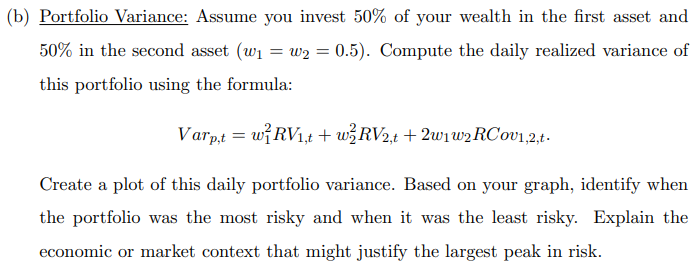

In [23]:
w1 = 0.5
w2 = 0.5

data['daily_portfolio_variance'] = (w1**2 * data['RV_JNJ']) + (w2**2 * data['RV_JPM']) + (2 * w1* w2 * data['rcov'])

data.head()

,date,RV_JNJ,RV_JPM,rcov,daily_corr,daily_portfolio_variance
0,2015-01-02,0.000092,0.000146,0.000048,0.414501,0.000084
1,2015-01-05,0.000077,0.000185,0.000044,0.369340,0.000088
2,2015-01-06,0.000147,0.000297,0.000092,0.438037,0.000157
3,2015-01-07,0.000107,0.000243,0.000072,0.447211,0.000124
4,2015-01-08,0.000049,0.000124,0.000022,0.285529,0.000055


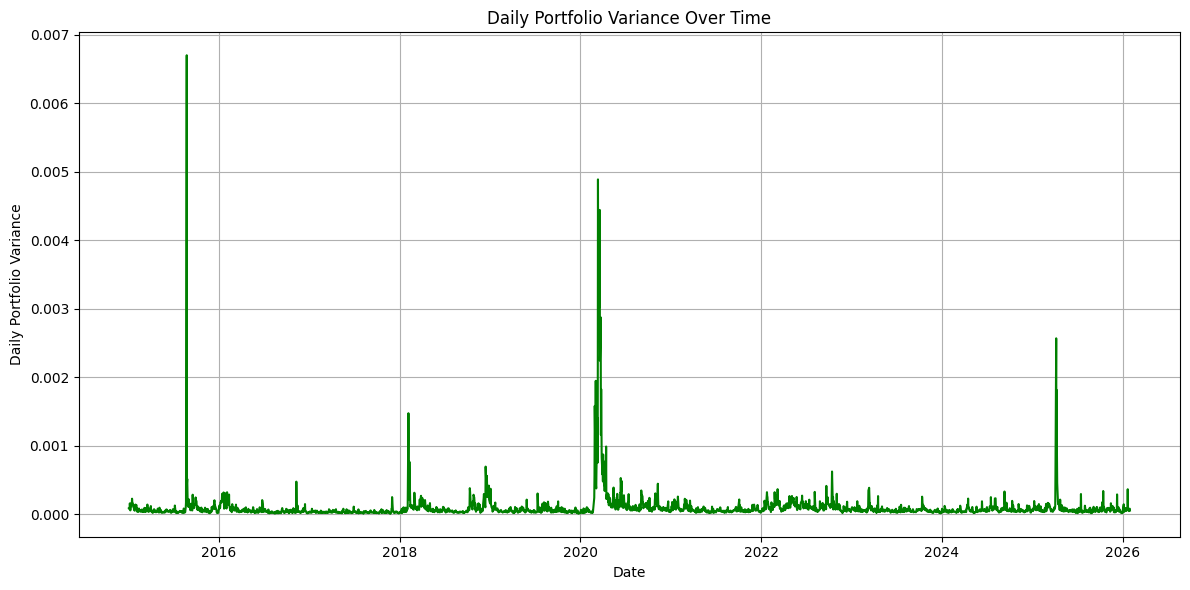

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(data['date'], data['daily_portfolio_variance'], 'g-')
plt.title('Daily Portfolio Variance Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Portfolio Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation**:  The daily portfolio variance of the equal-weighted JNJ (50%) and JPM (50%) portfolio remains low and relatively stable for most of the 2014–2026 period, indicating that the diversification between the two assets generally keeps risk contained, but three major spikes break this tranquility: a sharp peak around 2015–2016, a moderate elevation in 2018, and by far the largest spike in early 2020, which dwarfs all others reaching nearly 0.005, followed by a smaller but notable surge around 2025–2026. The most risky period is unambiguously March 2020, corresponding to the onset of the COVID-19 pandemic, where unprecedented simultaneous shocks hit both assets — JPM collapsed on emergency rate cuts to zero, frozen credit markets and collapsing net interest margins, while JNJ was dragged down by the broader market panic despite its defensive profile, meaning the correlation between the two temporarily surged toward 1 and the diversification benefit vanished precisely when it was most needed, causing portfolio variance to explode. Conversely, the least risky periods are the stretches of low, flat variance visible between 2021 and 2024, where macro conditions were more predictable, volatility was subdued, and the two assets moved with moderate and stable correlation, allowing the portfolio to benefit fully from its cross-sector diversification. This chart powerfully illustrates a core limitation of diversification: it tends to work well in calm regimes but breaks down during systemic crises, when asset correlations spike and portfolio variance surges regardless of how well-constructed the allocation was under normal conditions.

**Part 2: Quarterly Analysis (Daily Returns vs. Realized Measures)**

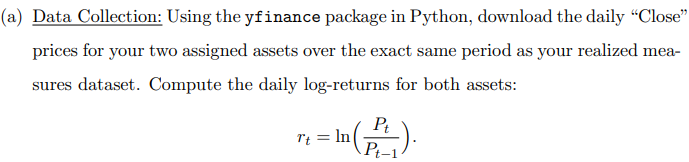

In [29]:
import yfinance as yf

# Get the date range from your existing data DataFrame
start_date = data['date'].min()
end_date = data['date'].max()

# Download both tickers at once
close_prices_df = yf.download(['JNJ', 'JPM'], start=start_date, end=end_date)['Close']
close_prices_df = close_prices_df.reset_index()
close_prices_df.columns.name = None
close_prices_df = close_prices_df.rename(columns={'Date': 'date', 'JNJ': 'JNJ_Close', 'JPM': 'JPM_Close'})
close_prices_df['date'] = pd.to_datetime(close_prices_df['date'])

# Merge with existing data
data['date'] = pd.to_datetime(data['date'])
data = pd.merge(data, close_prices_df, on='date', how='left')

# Compute log returns
data['log_return_JNJ'] = np.log(data['JNJ_Close'] / data['JNJ_Close'].shift(1))
data['log_return_JPM'] = np.log(data['JPM_Close'] / data['JPM_Close'].shift(1))

print("Done")
display(data.head())

/tmp/ipykernel_7600/3973139880.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  close_prices_df = yf.download(['JNJ', 'JPM'], start=start_date, end=end_date)['Close']
[*********************100%***********************]  2 of 2 completed

Done


,date,RV_JNJ,RV_JPM,rcov,daily_corr,daily_portfolio_variance,JNJ_Close,JPM_Close,log_return_JNJ,log_return_JPM
0,2015-01-02,0.000092,0.000146,0.000048,0.414501,0.000084,76.548630,46.274319,NaN,NaN
1,2015-01-05,0.000077,0.000185,0.000044,0.369340,0.000088,76.013977,44.837734,-0.007009,-0.031537
2,2015-01-06,0.000147,0.000297,0.000092,0.438037,0.000157,75.640457,43.675125,-0.004926,-0.026271
3,2015-01-07,0.000107,0.000243,0.000072,0.447211,0.000124,77.310287,43.741787,0.021836,0.001525
4,2015-01-08,0.000049,0.000124,0.000022,0.285529,0.000055,77.918175,44.719254,0.007832,0.022100


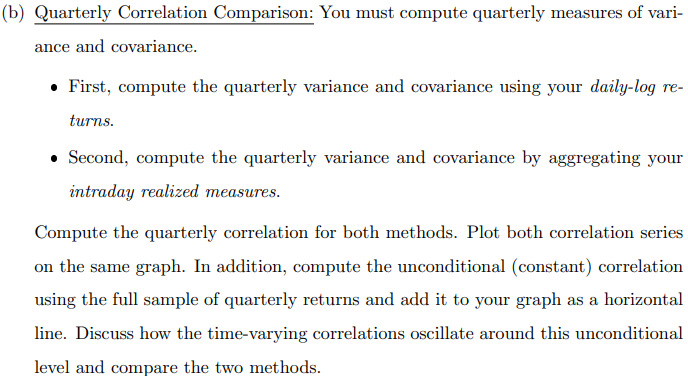

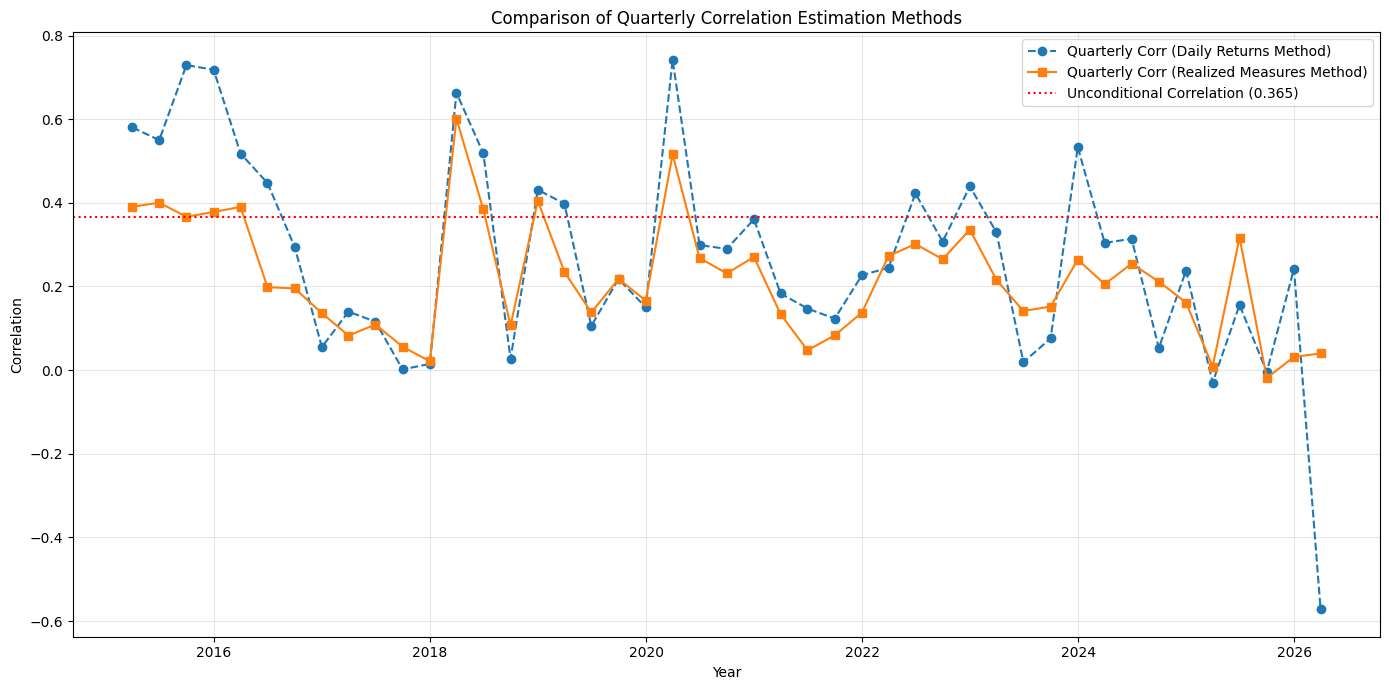

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fix: Only set index if 'date' is still a column to avoid KeyError
if 'date' in data.columns:
    data.set_index('date', inplace=True)

# 1. Quarterly Measures using Daily Log Returns (Sample Var/Cov)
# We calculate the correlation of daily returns within each quarter
# Use 'QE' for Quarter End frequency
quarterly_ret_corr = data.resample('QE').apply(lambda x: x['log_return_JNJ'].corr(x['log_return_JPM']))

# 2. Quarterly Measures using Aggregated Realized Measures
# Realized variance and covariance are additive
quarterly_realized = data[['RV_JNJ', 'RV_JPM', 'rcov']].resample('QE').sum()
quarterly_realized_corr = quarterly_realized['rcov'] / (np.sqrt(quarterly_realized['RV_JNJ']) * np.sqrt(quarterly_realized['RV_JPM']))

# 3. Unconditional Correlation (Full Sample Constant)
# Calculated using the correlation of all daily log returns in the dataset
unconditional_corr = data['log_return_JNJ'].corr(data['log_return_JPM'])

# Prepare plotting data
plt.figure(figsize=(14, 7))
plt.plot(quarterly_ret_corr.index, quarterly_ret_corr, label='Quarterly Corr (Daily Returns Method)', marker='o', linestyle='--')
plt.plot(quarterly_realized_corr.index, quarterly_realized_corr, label='Quarterly Corr (Realized Measures Method)', marker='s', linestyle='-')
plt.axhline(y=unconditional_corr, color='r', linestyle=':', label=f'Unconditional Correlation ({unconditional_corr:.3f})')

plt.title('Comparison of Quarterly Correlation Estimation Methods')
plt.xlabel('Year')
plt.ylabel('Correlation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Restore index for future cells if needed
data.reset_index(inplace=True)

**Interpretation:**

The unconditional correlation of 0.365 acts as a long run gravitational centre around which both series oscillate throughout the 2015–2026 period, but neither method stays close to it for long, confirming that correlation between JNJ and JPM is genuinely time varying and regime dependent. Both series spend roughly equal time above and below the unconditional level, with notable spikes upward in 2015–2016 and around 2020 — the latter corresponding to the COVID crash where panic driven selling temporarily synchronised the two assets — and significant drops toward or below zero in 2018, 2023–2024, and most strikingly in early 2026 where the daily returns method plunges to nearly –0.6, suggesting a sharp divergence episode likely driven by sector specific shocks. Regarding the comparison of the two methods, the realized measures correlation (orange) is visibly smoother and more stable quarter to quarter, which is expected since it aggregates hundreds of intraday observations and is therefore less sensitive to the noise of a handful of daily return observations; the daily returns method (blue) is considerably more volatile and erratic, occasionally producing extreme values that likely reflect small sample estimation error within a single quarter rather than true economic shifts. This is precisely the theoretical advantage of realized measures: by exploiting high frequency data, they produce more efficient and less noisy estimates of the true underlying correlation, making them more reliable for portfolio construction and risk management than their daily return based counterparts.

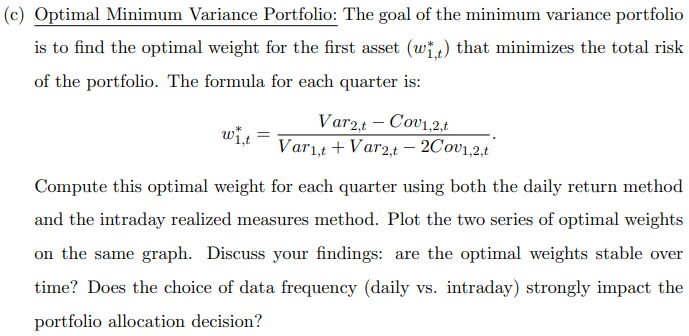

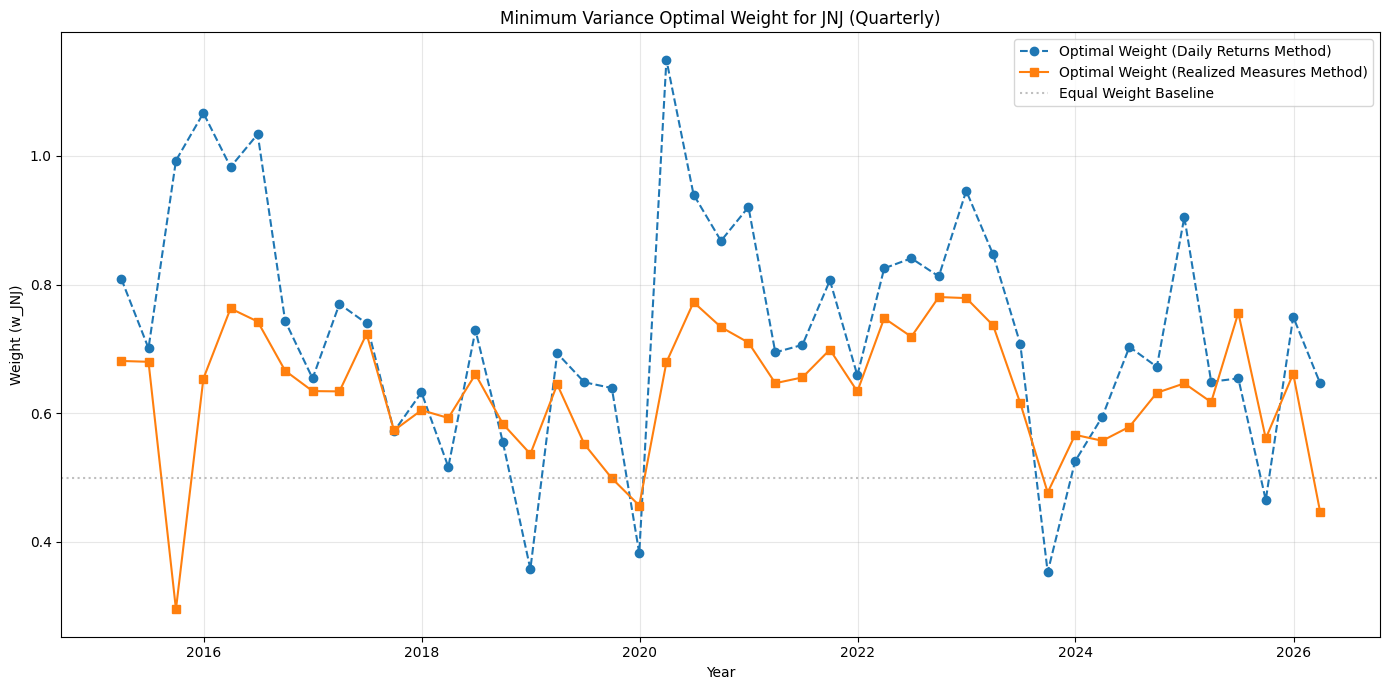

In [47]:
# Function to calculate optimal weight for asset 1 (JNJ) in a 2-asset minimum variance portfolio
# Formula: w1* = (var2 - cov12) / (var1 + var2 - 2*cov12)
def calc_optimal_weight(var_jnj, var_jpm, cov):
    return (var_jpm - cov) / (var_jnj + var_jpm - 2 * cov)

# Ensure date is the index before resampling
if 'date' in data.columns:
    data.set_index('date', inplace=True)

# 1. Optimal Weights using Daily Returns Method
# Calculate individual variance series
var_jnj_ret = data['log_return_JNJ'].resample('QE').var()
var_jpm_ret = data['log_return_JPM'].resample('QE').var()

# Correctly extract quarterly covariance
# We use a lambda on the resampler to ensure we get the covariance between the two columns
cov_ret = data.resample('QE').apply(lambda x: x[['log_return_JNJ', 'log_return_JPM']].cov().iloc[0, 1])

# Calculate weights using the daily returns statistics
opt_w_ret = calc_optimal_weight(var_jnj_ret, var_jpm_ret, cov_ret)

# 2. Optimal Weights using Realized Measures Method
# Realized measures were aggregated in the previous step (quarterly_realized)
opt_w_realized = calc_optimal_weight(
    quarterly_realized['RV_JNJ'],
    quarterly_realized['RV_JPM'],
    quarterly_realized['rcov']
)

# Plotting the results
plt.figure(figsize=(14, 7))
plt.plot(opt_w_ret.index, opt_w_ret, label='Optimal Weight (Daily Returns Method)', marker='o', linestyle='--')
plt.plot(opt_w_realized.index, opt_w_realized, label='Optimal Weight (Realized Measures Method)', marker='s', linestyle='-')

plt.title('Minimum Variance Optimal Weight for JNJ (Quarterly)')
plt.xlabel('Year')
plt.ylabel('Weight (w_JNJ)')
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Equal Weight Baseline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Restore index for consistency with earlier parts of the notebook
data.reset_index(inplace=True)

**Interpretation :** The optimal weights are clearly not stable over time — both series fluctuate substantially across the entire 2015–2026 period, ranging roughly between 0.3 and 1.1 for the daily returns method and between 0.3 and 0.8 for the realized measures method, meaning the minimum variance portfolio would require significant rebalancing every quarter if these estimates were used directly for allocation. The weight consistently stays above the 0.5 equal-weight baseline for most of the sample, indicating that JNJ systematically contributes less variance to the portfolio than JPM and should therefore receive a larger allocation — which is consistent with JNJ being a defensive Healthcare stock with structurally lower volatility than the cyclical JPM. Regarding the impact of data frequency, the two methods tell broadly the same story in terms of direction and trend, confirming that both capture the same underlying economic dynamics, but the daily returns method (blue) is considerably more erratic and produces extreme values above 1.0 — most notably in Q1 2020 where it spikes to nearly 1.15, implying a short position in JPM — which are likely small-sample estimation artifacts rather than genuine signals. The realized measures method (orange) is smoother, more contained, and never breaches the [0, 1] boundary in any meaningful way, making it more suitable for practical portfolio construction. The conclusion is therefore that data frequency does matter: while both methods agree on the general allocation direction, the intraday realized measures method produces more stable and reliable weight estimates, reducing the risk of overreacting to noise and incurring unnecessary transaction costs from excessive rebalancing.